In [1]:
import os
import json
from pathlib import Path

import torch
from transformers import (
    Qwen2VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
)
from qwen_vl_utils import process_vision_info

MODEL_DIR = Path(r"./models/qwen2.5_vlm_2b") # указываем путь до используемой модели
IMAGE_DIR = "./data"
OUTPUT_FILE = "dataset.jsonl"

if not MODEL_DIR.is_dir():
    raise FileNotFoundError(f"Каталог модели не найден: {MODEL_DIR}")

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
)

MAX_NEW_TOKENS = 128
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}

model = Qwen2VLForConditionalGeneration.from_pretrained(
    str(MODEL_DIR),
    device_map="auto",
    torch_dtype=torch.float16,
    quantization_config=quantization_config,
    local_files_only=True,
)

processor = AutoProcessor.from_pretrained(
    str(MODEL_DIR),
    local_files_only=True,
)

print("Модель загружена из:", MODEL_DIR.resolve())


c:\Users\Nadia\Desktop\Python_ITMO\qvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0603 01:26:49.747000 11644 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
Loading weights: 100%|██████████| 729/729 [00:21<00:00, 33.60it/s]


Модель загружена из: C:\Users\Nadia\Desktop\Python_ITMO\qvenv\models\qwen2.5_vlm_2b


In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected")

PyTorch version: 2.13.0.dev20260602+cu130
CUDA available: True
CUDA version: 13.0
Device name: NVIDIA GeForce GTX 1650


In [ ]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

# Скачать модель в локальную папку
model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct",
    cache_dir="./models/qwen2.5_vlm_2b"  # сохранить здесь
)

c:\Users\Nadia\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Nadia\Desktop\Python_ITMO\models\qwen2.5_vlm_2b\models--Qwen--Qwen2-VL-2B-Instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

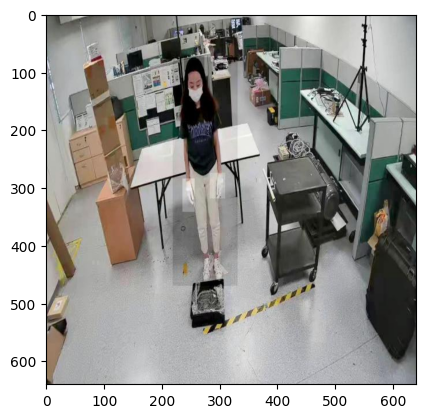

c:\Users\Nadia\Desktop\Python_ITMO\qvenv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Промпт: Сколько людей в кадре? Опиши их очень подробно
Ответ: В кадре есть одна человек. Она стоит на черной площадке, которая находится на зеленом поле. Вокруг нее видны различные предметы, включая мебель, оборудование и различные предметы, которые могут быть использованы в научных или исследовательских целях.


In [13]:
import matplotlib.pyplot as plt
import cv2

TEST_IMAGE = Path("./data/-01-16-2-4-2-2-33_jpg.rf.e314997ea7789b9c5f6124c04783d3a7.jpg")  # путь к картинке

image = cv2.imread(str(TEST_IMAGE))[:,:,::-1]
plt.imshow(image)
plt.show()

TEST_PROMPT = "Сколько людей в кадре? Опиши их очень подробно"

if not TEST_IMAGE.is_file():
    raise FileNotFoundError(f"Картинка не найдена: {TEST_IMAGE.resolve()}")

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": str(TEST_IMAGE)},
            {"type": "text", "text": TEST_PROMPT},
        ],
    }
]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

image_inputs, video_inputs = process_vision_info(messages)

inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to(model.device)

generated_ids = model.generate(
    **inputs,
    max_new_tokens=128,
    do_sample=False,
)

generated_ids_trimmed = [
    out_ids[len(in_ids):]
    for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]

answer = processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False,
)[0]

print("Промпт:", TEST_PROMPT)
print("Ответ:", answer)


[[[108 110 104]
  [108 110 104]
  [108 110 104]
  ...
  [ 49  54  53]
  [ 49  54  53]
  [ 49  54  53]]

 [[108 110 104]
  [108 110 104]
  [108 110 104]
  ...
  [ 48  53  52]
  [ 48  53  52]
  [ 48  53  52]]

 [[108 110 104]
  [108 110 104]
  [108 110 104]
  ...
  [ 47  52  51]
  [ 48  53  52]
  [ 48  53  52]]

 ...

 [[ 17  15  14]
  [ 12  10   9]
  [ 11   9   8]
  ...
  [ 56  52  51]
  [ 55  51  50]
  [ 55  51  50]]

 [[ 16  14  13]
  [ 12  10   9]
  [ 11   9   8]
  ...
  [ 56  52  51]
  [ 55  51  50]
  [ 54  50  49]]

 [[ 16  14  13]
  [ 12  10   9]
  [ 11   9   8]
  ...
  [ 56  52  51]
  [ 55  51  50]
  [ 54  50  49]]]


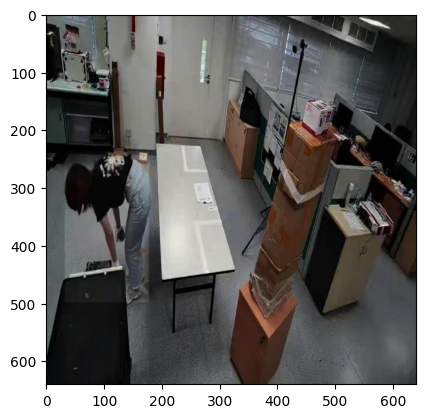

c:\Users\Nadia\Desktop\Python_ITMO\qvenv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Промпт: Сколько людей в кадре? Опиши их очень подробно
Ответ: В кадре есть три человека. Это:

1. Девушка, которая стоит у стола, смотрит на что-то, возможно, на что-то подняла в руках.
2. Два человека, которые находятся на заднем плане, видны только их тела, но они смотрят вперед, возможно, на что-то, которое делает девочка.
3. Девушка, которая стоит у стола, смотрит вниз, возможно, на что-то подняла в руках.


In [12]:
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

TEST_IMAGE = Path("./data/-01-16-2-3-2-5-15_jpg.rf.3a82c0e7cb6b006df4c9fc87d9b55368.jpg")

# image = cv2.imread(str(TEST_IMAGE))[:, :, ::-1]
img = cv2.imread(str(TEST_IMAGE))
print (img)
# Потом применяем срез (если img = None, ошибка будет здесь, но уже понятнее)
image = img[:, :, ::-1]  # TypeError: 'NoneType' object is not subscriptable
plt.imshow(image)
plt.show()

TEST_PROMPT = "Сколько людей в кадре? Опиши их очень подробно"

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": str(TEST_IMAGE)},
            {"type": "text", "text": TEST_PROMPT},
        ],
    }
]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

image_inputs, video_inputs = process_vision_info(messages)

inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to(model.device)

generated_ids = model.generate(
    **inputs,
    max_new_tokens=128,
    do_sample=False,
)

generated_ids_trimmed = [
    out_ids[len(in_ids):]
    for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]

answer = processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False,
)[0]

print("Промпт:", TEST_PROMPT)
print("Ответ:", answer)

In [16]:

PROMPT = """
Опиши изображение кратко и информативно.
Укажи:
- главные объекты
- действия
- сцену
Ответь одним предложением.
ОПИСЫВАЙ МАКСИМАЛЬНО ПОДРОБНО, КАЖДЫЙ ЭЛЕМЕНТ, КАЖДОЕ ДЕЙСТВИЕ!!!
"""

all_items = []

files = sorted(os.listdir(IMAGE_DIR))

for file_name in files:

    if not file_name.lower().endswith(
        (".jpg", ".jpeg", ".png", ".webp")
    ):
        continue

    image_path = os.path.join(IMAGE_DIR, file_name)

    print(f"Processing: {file_name}")

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image_path
                },
                {
                    "type": "text",
                    "text": PROMPT
                }
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    )

    inputs = inputs.to(model.device)

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=512,
        do_sample=False
    )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(
            inputs.input_ids,
            generated_ids
        )
    ]

    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    item = {
        "image": image_path,
        "text": output_text
    }

    all_items.append(item)

    print(output_text)


Processing: -01-16-2-3-2-5-15_jpg.rf.3a82c0e7cb6b006df4c9fc87d9b55368.jpg
В изображении представлено просторное помещение, возможно, это офис или учебный класс. На переднем плане видны несколько стеллажей, на которых хранятся различные предметы, включая коробки. В центре изображения находится стол, на котором лежит несколько папок. В левом углу можно увидеть человека, который занимается чем-то на полке.
Processing: -01-16-2-3-2-5-15_jpg.rf.705a29a51fa44f15dbe29adcaf09d2e0.jpg
На изображении представлено просторное помещение, возможно, это лаборатория или офис. В центре находится длинный стол, на котором лежит несколько коробок. Вокруг стола и на поле видны различные предметы, включая мебель, например, на заднем плане видны мебельные шкафы. Вокруг стола есть люди, которые занимаются чем-то, неизвестно, что они делают.
Processing: -01-16-2-3-2-5-20_jpg.rf.ff89baa4ddffc68390a744645a32236d.jpg
На изображении представлено помещение, в котором видны несколько людей, сидящих за столами, а так

In [17]:


with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    for item in all_items:
        f.write(
            json.dumps(item, ensure_ascii=False) + "\n"
        )

print(f"Saved to {OUTPUT_FILE}")


Saved to dataset.jsonl
